Nomes:  
Afonso Henrique C de Oliveira - RA: 235385  
Gabrielle Amaro Marchioli - RA: 236775  
Giulianno Giaciani Gonçalves - RA: 235484  
Kaique Vecchia Alves - RA: 235446  
Nathalia Atamanchuk Baleeiro - RA: 235215  

# Aula Lab. 5 - OpenCV
## Interpolação
Nestes exercícios vamos aprender duas formas básicas de interpolação:

* Vizinho mais próximo (Nearest neighbor)
* Bilinear

Começamos com o cabeçalho padrão:

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math

cv.samples.addSamplesDataSearchPath("data")

### Interpolação Nearest

Ou arredondamento (round). É a forma mais simples e direta de interpolação.

Caso uma coordenada transformada possua valor decimal, ou seja, não resulte em uma posição de pixel inteira, o valor é arredondado utilizando a regra tradiconal:

* Se &frac12; &ge; valor &lt; prox.int. => prox.int.
* Se valor &lt; &frac12; => valor

Ou seja:
* de [0.5 até 1.5) é 1
* de [1.5 até 2.5) é 2
* ...

A ccordenada de um pixel é seu centro.

<img src="https://upload.wikimedia.org/wikipedia/commons/4/47/Piecewise_constant.svg" style="background-color: #ffffff;" width="25%">
<img src="https://upload.wikimedia.org/wikipedia/commons/2/27/Interpolation-nearest.svg" width="25%">

## Exercício

Vamos começar criando uma função para cada transformação de afinidade:

In [2]:
def getTranslateAffine(tx, ty):
    if tx is None or ty is None:
        raise TypeError("Arguments cannot be None")
    return np.float32([
        [1, 0, tx],
        [0, 1, ty]
    ])

def getSCaleAffine(sx, sy):
    if sx is None or sy is None:
        raise TypeError("Arguments cannot be None")
    if not sx or not sy:
        raise TypeError("Arguments cannot be Zero")
    return np.float32([
        [sx, 0,  0],
        [0,  sy, 0]
    ])

def getRotationAffine(degree, center=(0,0)):
    if degree is None:
        raise TypeError("Argument cannot be None")
    tx, ty = center
    theta = math.radians(-1 * degree)
    cos_t, sin_t = math.cos(theta), math.sin(theta)
    # Rotação em torno de um centro: translada p/ origem, rotaciona, translada de volta
    return np.float32([
        [cos_t, -sin_t, tx - tx*cos_t + ty*sin_t],
        [sin_t,  cos_t, ty - tx*sin_t - ty*cos_t]
    ])

def getShearAffine(sx, sy):
    if sx is None or sy is None:
        raise TypeError("Arguments cannot be None")
    return np.float32([
        [1,  sx, 0],
        [sy, 1,  0]
    ])

Agora crie uma função myAffineNearest(img, mat)

> Primiera nota, cuidado com round do Python, ele arredonda 2.5 para 2 e 3.5 para 4, procure sobre Bankers Rounding
>
> Então usaremos np.ceil: $\left\lceil x \right\rceil$

In [3]:
def myAffineNearest(img, mat):
    if img is None or mat is None:
        raise TypeError("Arguments cannot be None")
    
    l, c = img.shape           # linhas, colunas (grayscale 1 canal)
    dst = np.zeros((l, c), dtype=np.uint8)
    
    # Inversa da matriz afim (2x3 → precisa da linha [0,0,1] para inverter)
    M_full = np.vstack([mat, [0, 0, 1]])
    M_inv  = np.linalg.inv(M_full)[:2]  # de volta para 2x3

    for v in range(l):
        for u in range(c):
            # Coordenada destino → origem (mapeamento inverso)
            src_coords = np.matmul(M_inv, np.float32([u, v, 1]))
            x = int(np.ceil(src_coords[0] - 0.5))  # nearest via ceil(x - 0.5)
            y = int(np.ceil(src_coords[1] - 0.5))

            if 0 <= x < c and 0 <= y < l:
                dst[v, u] = img[y, x]
            # else: permanece 0
    
    return dst

Agora vamos testar nossa função

1. carregue Lena.jpg com ROI de 2 linhas e 5 colunas a partir da origem

In [5]:
lena_raw = cv.imread(cv.samples.findFile("data/Lena.jpg"), cv.IMREAD_GRAYSCALE)
lena_2x5 = lena_raw[0:2, 0:5]

2. Agora transforme a imagem com translate de 2px para a direita

In [6]:
lena_2x5_t = myAffineNearest(lena_2x5, getTranslateAffine(2.5, 0))

3. Vamos ver o resultado com print, perceba o deslocamento dos pixels

In [7]:
print(lena_2x5)
print()
print(lena_2x5_t)

[[163 162 161 160 163]
 [162 162 162 161 163]]

[[  0   0   0 163 162]
 [  0   0   0 162 162]]


Mas 2.5 não seria arredondado para 3? Lembre-se que $x = u - tx$. Então teremos:

$\left\lceil -2.5 \right\rceil = -2$ pois $-2 \gt -2.5$

Ceil arredonda para o próximo **maior** inteiro.

|u|x|$\left\lceil x \right\rceil$|
|:---:|:---:|:---:|
|0|-2.5|-2|
|1|-1.5|-1|
|2|-0.5|0|
|3|0.5|1|
|4|1.5|2|

> Segunda nota, cuidado com Matplot. Matplot foi feito para plotar gráficos, não como visualizador de imagens, ele naturalmente faz ajustes para facilitar a visualização, entre eles:
> * ajuste automático do máximo e mínimo de x e y
> * interpolação bilinear da área do gráfico
> * mapa de cores de [vmin]branco até [vmax]azul
>
> Precisamos sempre passar como argumentos: *..., cmap='gray', interpolation='nearest', vmin=0, vmax=255)*
> quando trabalhamos com imagens (podemos omitir *cmap* se a imagem for RGB)

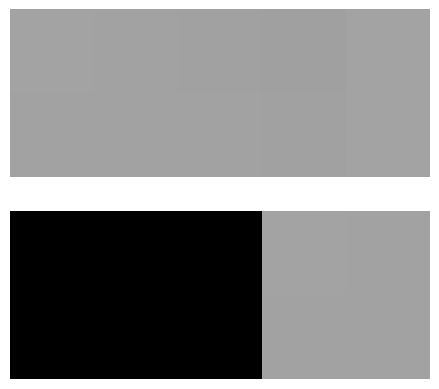

In [8]:
plt.subplot(2,1,1)
plt.imshow(lena_2x5, cmap='gray', interpolation='nearest', vmin=0, vmax=255)
plt.axis('off')
plt.subplot(2,1,2)
plt.imshow(lena_2x5_t, cmap='gray', interpolation='nearest', vmin=0, vmax=255)
plt.axis('off')
plt.show()

## Interpolação Bilinear

A interpolação bilinear é a interpolação linear aplicada em ambos os eixos, horizontal e vertical.

É uma forma simples de interpolação que leva em consideração os 4 pixels adjacentes à coordenada que desejamos calcular:

<table><tr>
<td><img src="https://upload.wikimedia.org/wikipedia/commons/a/a7/Bilin3.png" width="70%">
</td><td><ul>
<li>(0,0) = &lfloor;x&rfloor;, &lfloor;y&rfloor;</li>
<li>(1,0) = &lfloor;x&rfloor;+1, &lfloor;y&rfloor;</li>
<li>(0,1) = &lfloor;x&rfloor;, &lfloor;y&rfloor;+1</li>
<li>(1,1) = &lfloor;x&rfloor;+1, &lfloor;y&rfloor;+1</li>
</ul></td>
</tr></table>

Veja que usamos *Floor*, que retorna o menor inteiro.

A interpolação bilenar também é conhecido como a média ponderada de 4 pixels:

<img src="https://upload.wikimedia.org/wikipedia/commons/9/91/Bilinear_interpolation_visualisation.svg" style="background-color: #ffffff;" width="25%">
Valor<sub>final</sub> = P<sub>amarelo</sub>&sdot;A<sub>amarelo</sub> + P<sub>azul</sub>&sdot;A<sub>azul</sub> + P<sub>verde</sub>&sdot;A<sub>verde</sub> + P<sub>vermelha</sub>&sdot;A<sub>vermelha</sub>

Onde

* A<sub>amarela</sub> = (x<sub>2</sub>-x)*(y-y<sub>1</sub>)
* A<sub>azul</sub> = (x-x<sub>1</sub>)*(y-y<sub>1</sub>)
* A<sub>verde</sub> = (x<sub>2</sub>-x)*(y<sub>2</sub>-y)
* A<sub>vermelha</sub> = (x-x<sub>1</sub>)*(y<sub>2</sub>-y)

## Exercício

Vamos criar uma função myAffineBilinear(img, mat)

In [9]:
def myAffineBilinear(img, mat):
    if img is None or mat is None:
        raise TypeError("Arguments cannot be None")
    
    l, c = img.shape
    dst = np.zeros((l, c), dtype=np.uint8)

    M_full = np.vstack([mat, [0, 0, 1]])
    M_inv  = np.linalg.inv(M_full)[:2]

    for v in range(l):
        for u in range(c):
            src = np.matmul(M_inv, np.float32([u, v, 1]))
            x, y = src[0], src[1]

            x0 = int(np.floor(x))
            x1 = x0 + 1
            y0 = int(np.floor(y))
            y1 = y0 + 1

            # Pega os 4 pixels vizinhos, 0 se fora dos limites
            def get_px(row, col):
                if 0 <= row < l and 0 <= col < c:
                    return float(img[row, col])
                return 0.0

            Ia = get_px(y0, x0)
            Ib = get_px(y0, x1)
            Ic = get_px(y1, x0)
            Id = get_px(y1, x1)

            # Pesos = áreas opostas
            wa = (x1 - x) * (y1 - y)
            wb = (x  - x0) * (y1 - y)
            wc = (x1 - x) * (y  - y0)
            wd = (x  - x0) * (y  - y0)

            dst[v, u] = np.clip(wa*Ia + wb*Ib + wc*Ic + wd*Id, 0, 255)
    
    return dst

Vamos verificar nossa implementação.

1. Carregue novamente a lena, mas com ROI de 128x128 pixels começando de 64x64

In [10]:
lena128  = lena_raw[64:192, 64:192]

2. Aplica a transfomração de escala nearest e de escala bilinear com um fator de 1.5 em x

In [11]:
M_scale  = getSCaleAffine(1.5, 1.0)
lena128b = myAffineBilinear(lena128, M_scale)
lena128n = myAffineNearest(lena128, M_scale)

3. Vamos ver o resultado

É bem sutil, perceba as listras do chapéu da lena como estão mais suaves na forma interpolada

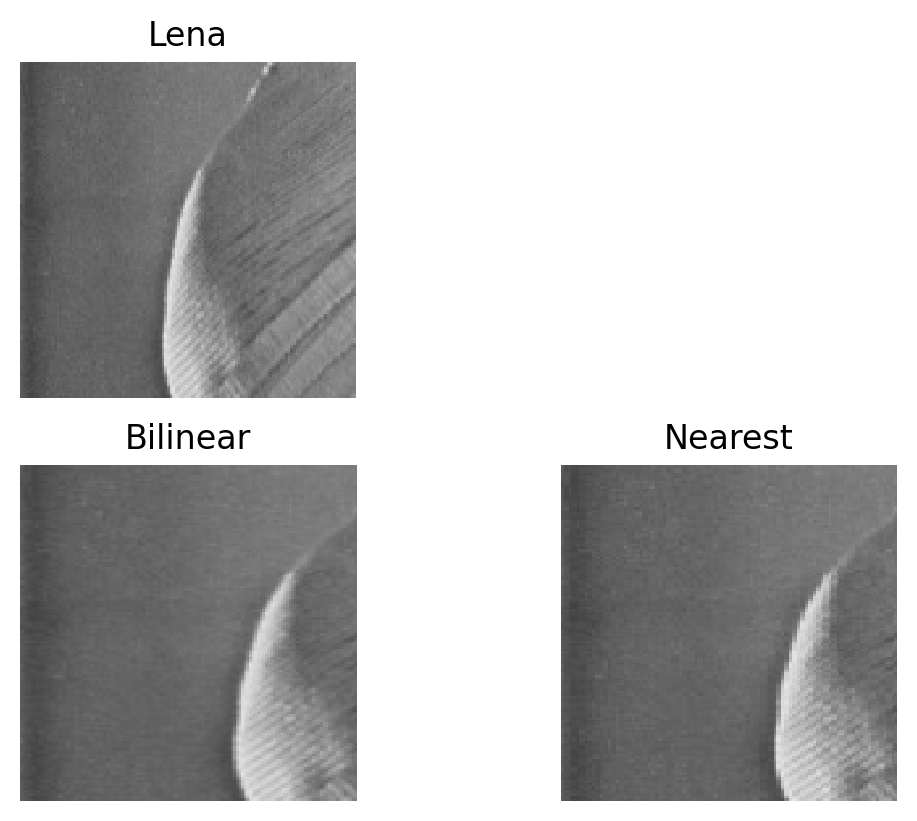

In [12]:
ax = plt.subplot(2,2,1)
ax.set_title("Lena")
plt.imshow(lena128,  cmap='gray', interpolation='nearest', vmin=0, vmax=255)
plt.axis('off')
ax = plt.subplot(2,2,3)
ax.set_title("Bilinear")
plt.imshow(lena128b, cmap='gray', interpolation='nearest', vmin=0, vmax=255)
plt.axis('off')
ax = plt.subplot(2,2,4)
ax.set_title("Nearest")
plt.imshow(lena128n, cmap='gray', interpolation='nearest', vmin=0, vmax=255)
plt.axis('off')
plt.gcf().set_dpi(200)
plt.show()